In [2]:
import numpy as np
import matplotlib.pyplot as plt
import simulation_cpu as sim
import scipy.special as scp
import analyze_tool as an

In [3]:
# magnets matirals proprety

# cobalt
Co_er = 1
Co_sigma = 1.7e7 #https://periodictable.com/Elements/027/data.html
Co_er_complex= -16 + 23.3j 

# Iron
Fe_er = 1
Fe_sigma = 1e7

# nical
Ni_er = 1
Ni_sigma = 1.4e7 #https://periodictable.com/Elements/027/data.html 

alpae_renge = (0.025 ,0.0025) #genral range
gilbert_damping_time = 600e-12 #[sec] artical - concting to alpha in {I dont remmber how}
precession_frequency = 8.5e9 #[Hz] artical

# aditinal matirals proprety
Pt_er = 1
Pt_sigma = 7e6 # [1/oham*m]

Au_er = 1
Au_sigma = 1e6 # (spintronics lab)


alpha = {"Co_Au" : 0.02, "Co_Pt" : 0.025 , "Fe_Au": 0.02, "Fe_Pt" : 0.025, "Ni_Au": 0.05, "Ni_Pt" : 0.06}

key_name = [
            "H times picture",
            "E times picture",
            "ms time picture",
            "time picture",
            "H in locations",
            "E in locations",
            "ms in locations",
            "locations",
            "time intervals",
            "matitral location", "e_r" ,"conductivity", "gilbert damping factor","initial magnetization",
            "max magnetic field" ,"polarization phase","pulse width (FWHM)",
            "systen status", "dt", "safety_start"                
            ]

In [7]:

# pulse proprty (in the article)
mean_wave_lenght= 784e-9 # [m]
# B_opt =  [0.02, 0.2 ] # [T]
# FWHM = 1.1e-12 #[sec]
B_opt =2.4e5 #[A/m ] = 0.3[T]

w= 2*np.pi/(mean_wave_lenght/sim.c)

path = "C:\maxwell-LLG\ws\simulation_result\Full_Width_Pulse\\"




# besic stuff
time_cycal= mean_wave_lenght/sim.c
FWHM = 5* time_cycal #[sec]


dz = 2e-9/8
dt = dz/(2*sim.c)

# matiral length according to arcticle
magntic_steps = 10e-9//dz
conductive_steps = 2e-9//dz

# pulse properties
sefe_start = 3
sigma_pulse = 0.5* (np.log(2)**-0.5) * FWHM
peak_enter_time= sefe_start * sigma_pulse
fie = np.pi/2

#material properties
magntic_name = ["Co", "Fe", "Ni"]
conductive_name = ["Au", "Pt"]

magntic_eps = [Co_er, Fe_er, Ni_er ]
conductive_eps = [  Au_er, Pt_er]

magntic_sigma = [Co_sigma, Fe_sigma, Ni_sigma ]
conductive_sigma = [ Au_sigma, Pt_sigma]

ms0 = 3e5*np.array([1, 0, 0 , 0 ,0, -0.0001]).reshape((2,3))

#simulation building blocks
z1 = 8
# z1 = 20
z_end = int(z1+ magntic_steps + conductive_steps)
z_indexes = [z1, int(z1+ magntic_steps), z_end ]


save_loc = [4, int(z1), int(z1+ magntic_steps), z_end+1]
# save_loc[0] = 4
# save_time= []


void_steps = 2*z1

exit_steps = int(time_cycal/ dt)



simulation_time = int(3*(peak_enter_time//dt + void_steps +4* (magntic_steps + conductive_steps)) + exit_steps)
save_time= [int(0.3*simulation_time)]

In [9]:
feild_save_ind = [0, 1,0, -1]


epsr_list = [magntic_eps[0], conductive_eps[0]]
sigma_list = [magntic_sigma[0], conductive_sigma[0]]


data = sim.simulation(z_indexes, epsr_list , sigma_list, alpha[magntic_name[0] +"_" + conductive_name[0]] , ms0,
        B_opt, fie , FWHM,
        save_loc, save_time, False,
        dt, simulation_time, lamda=mean_wave_lenght, safety_start= sefe_start, time_interval= 7 )

# z2_in_ms = data["matitral location"][1]-data["matitral location"][0]
# feild_save_ind[3] = z2_in_ms+ 1

# data["H in locations"] = data["H in locations"][:,feild_save_ind,:]
# data["E in locations"] = data["E in locations"][:,feild_save_ind,:]






simulation pross: 100%|██████████| 176383/176383 [01:19<00:00, 2219.74it/s]


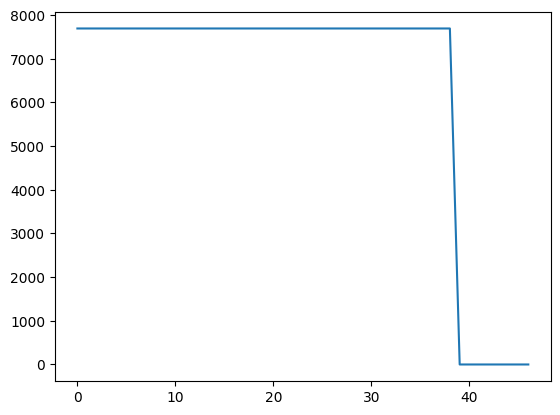

In [17]:
H = data["H in locations"]
# plt.plot(H[:, 0, 0])

ms = data["ms in locations"]
sim_cycle_steps = int(time_cycal/(data["dt"]*data["time intervals"]))
ms_z = ms[-3*sim_cycle_steps:,:z2_in_ms,2]
plt.plot(np.real(ms[0,:,0]))

In [ ]:
feild_save_ind = [0, 1,0, -1]

for mag in range(3):
    for cond in range(2):
        for close_sistem in [False, True]:

            file_name = path + magntic_name[mag] +"_" + conductive_name[cond] 
            
            if close_sistem:
                file_name += "_close.npy"
            else:
                file_name += "_open.npy"

            epsr_list = [magntic_eps[mag], conductive_eps[cond]]
            sigma_list = [magntic_sigma[mag], conductive_sigma[cond]]


            data = sim.simulation(z_indexes, epsr_list , sigma_list, alpha[magntic_name[mag] +"_" + conductive_name[cond]] , ms0,
                    B_opt, fie , FWHM,
                    save_loc, save_time, close_sistem,
                    dt, simulation_time, lamda=mean_wave_lenght, safety_start= sefe_start, time_interval= 7 )

            z2_in_ms = data["matitral location"][1]-data["matitral location"][0]
            feild_save_ind[3] = z2_in_ms+ 1
            data["H in locations"] = data["H in locations"][:,feild_save_ind,:]
            data["E in locations"] = data["E in locations"][:,feild_save_ind,:]
            np.save(file_name, data)





simulation pross: 100%|██████████| 12365131/12365131 [1:36:36<00:00, 2133.19it/s]


In [26]:
sim_name =  magntic_name[0] +"_" + conductive_name[0]
  


sim_name += "_close.npy"




data = np.load(path + sim_name, allow_pickle=True)
data = data.item()



-5.293955920339377e-23
-3.118140037079893e-20


Text(0.5, 1.0, 'Co_Au_close.npy')

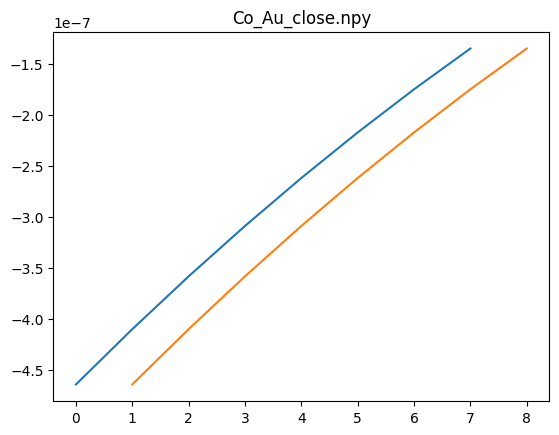

In [32]:
H = data["H in locations"]
ms  = data["ms in locations"]

z2_in_ms = data["matitral location"][1]-data["matitral location"][0]

sim_cycle_steps = int(time_cycal/(data["dt"]*data["time intervals"]))
mz_up = np.mean(np.real(ms[-2*sim_cycle_steps:,:z2_in_ms,2]), 0)
mz_to_m0 = mz_up/np.real(ms[0,:z2_in_ms,0])


mz_to_m0_in_every_time_step_every_dz = np.real(ms[-2*sim_cycle_steps:,:z2_in_ms,2])/np.real(ms[0:2*sim_cycle_steps,:z2_in_ms,0])
mz_to_m0_in_every_time_step = np.mean(mz_to_m0_in_every_time_step_every_dz,1)
mz_to_m0_in_every_dz = np.mean(mz_to_m0_in_every_time_step_every_dz,0)

print(np.mean(mz_to_m0_in_every_dz) - np.mean(mz_to_m0_in_every_time_step))
print(np.mean(mz_to_m0) - np.mean(mz_to_m0_in_every_time_step))


plt.plot(mz_to_m0_in_every_dz)
plt.plot(np.arange(1,9),mz_to_m0)
plt.title(sim_name)
# plt.plot(ms[0,:,0])

C:\Users\owner\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\LocalCache\local-packages\Python39\site-packages\matplotlib\cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
C:\Users\owner\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\LocalCache\local-packages\Python39\site-packages\matplotlib\cbook.py:1398: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


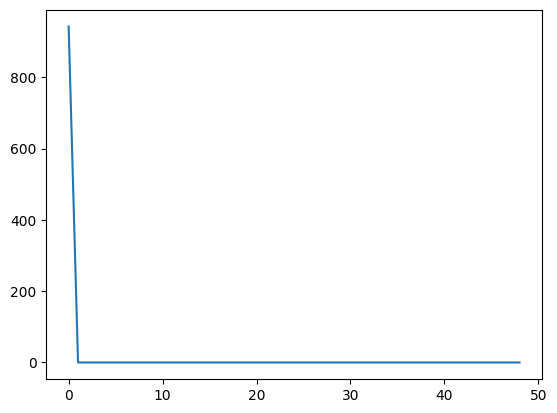

In [ ]:
H = data["H in locations"]
plt.plot(H[0, :, 0])

In [ ]:
H = data["H in locations"]
plt.plot(H[0, :, 0])


AttributeError: module 'numpy' has no attribute 'erf'